In [4]:
import json
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

with open('cocktails.json', 'r') as f:
    cocktails = json.load(f)

cocktail_texts = []
cocktail_ingredients_list = [] 

for c in cocktails:
    ingredients = [str(c[f'strIngredient{i}']) for i in range(1, 16) if c.get(f'strIngredient{i}')]
    
    cocktail_ingredients_list.extend(ingredients)
    
    cocktail_text = " ".join([
        c['strDrink'],
        c['strInstructions'],
        " ".join(ingredients)
    ])
    
    cocktail_texts.append(cocktail_text)

cocktail_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7, min_df=5)
cocktail_tfidf = cocktail_vectorizer.fit_transform(cocktail_texts)

k = 40  # Same as class demo
U, s, vt = svds(cocktail_tfidf, k=k)
cocktail_vectors = normalize(U, axis=1)

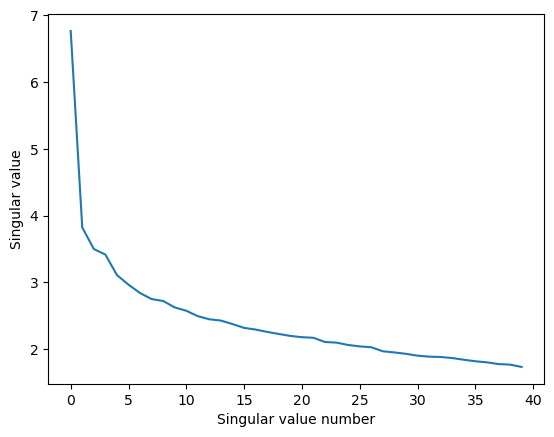

In [5]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(s[::-1])
plt.xlabel("Singular value number")
plt.ylabel("Singular value")
plt.show()